# Supervised
here we build out supervised models

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
import shap
print('done!')

done!


In [73]:
# read in the data frame
df = pd.read_csv('./df_labels.csv')

#drop unnamed cols
cols_Drop = [col for col in df.columns if 'Unnamed:' in col]
df = df.drop(cols_Drop, axis=1)

# add the per minutes columns
df['2PA_per_min'] = df['2PA'] / df['MP_x']
df['FTA_per_min'] = df['FTA'] / df['MP_x']
df['3PA_per_min'] = df['3PA'] / df['MP_x']
df['PF_per_min'] = df['PF'] / df['MP_x']

#show
df

,Age,G,GS,MP_x,FG,FGA,FG%,3P,3PA,3P%,...,Player,Team,cluster_3,cluster_9,cluster_3_label,cluster_9_label,2PA_per_min,FTA_per_min,3PA_per_min,PF_per_min
0,26.0,76.0,76.0,34.2,11.3,21.8,0.519,2.1,5.7,0.375,...,Shai Gilgeous-Alexander,OKC,0,0,High Volume Offensive Stars,Interior Scoring Stars,0.470760,0.257310,0.166667,0.064327
1,30.0,67.0,67.0,34.2,11.8,19.7,0.601,0.2,0.9,0.222,...,Giannis Antetokounmpo,MIL,0,0,High Volume Offensive Stars,Interior Scoring Stars,0.546784,0.309942,0.026316,0.067251
2,29.0,70.0,70.0,36.7,11.2,19.5,0.576,2.0,4.7,0.417,...,Nikola Jokić,DEN,0,0,High Volume Offensive Stars,Interior Scoring Stars,0.403270,0.174387,0.128065,0.062670
3,25.0,22.0,22.0,35.7,9.8,21.2,0.464,3.4,9.6,0.354,...,Luka Dončić,DAL,0,3,High Volume Offensive Stars,Primary Offensive Engines,0.322129,0.184874,0.268908,0.072829
4,25.0,28.0,28.0,35.1,8.8,20.0,0.438,3.6,9.6,0.379,...,Luka Dončić,LAL,0,3,High Volume Offensive Stars,Primary Offensive Engines,0.296296,0.253561,0.273504,0.068376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,23.0,20.0,0.0,6.3,0.6,1.7,0.324,0.1,0.9,0.059,...,Spencer Jones,DEN,1,4,Balanced Role Players,Low Usage Floor Spacers,0.142857,0.031746,0.142857,0.142857
547,26.0,33.0,2.0,7.0,0.4,1.6,0.245,0.2,1.0,0.156,...,Xavier Tillman Sr.,BOS,1,4,Balanced Role Players,Low Usage Floor Spacers,0.085714,0.014286,0.142857,0.071429
548,23.0,12.0,0.0,7.3,0.4,1.7,0.250,0.0,0.8,0.000,...,Luke Travers,CLE,1,4,Balanced Role Players,Low Usage Floor Spacers,0.123288,0.027397,0.109589,0.068493
549,25.0,19.0,0.0,5.3,0.4,1.1,0.381,0.1,0.5,0.200,...,Justin Minaya,POR,1,4,Balanced Role Players,Low Usage Floor Spacers,0.113208,0.018868,0.094340,0.113208


In [74]:
# subset to the columns we will be using
X = df[['2PA_per_min', 'FTA_per_min', 'USG%', 'PF_per_min', '3PA_per_min', 'TOV%', '3PAr', 'cluster_9']].copy()
y = df[['PER', 'WS']].copy()

# encode the cluster labels
X = pd.get_dummies(X, columns=['cluster_9'], drop_first=False)

# train test split
X_train_original, X_test_original, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_original)
X_test = scaler.transform(X_test_original)

### Linear Regression

In [88]:
# per
lin_mod_per = LinearRegression()
lin_mod_per.fit(X_train, y_train['PER'])

# ws
lin_mod_ws = LinearRegression()
lin_mod_ws.fit(X_train, y_train['WS'])

# predict
y_train_pred_per = lin_mod_per.predict(X_train)
y_test_pred_per = lin_mod_per.predict(X_test)

y_train_pred_ws = lin_mod_ws.predict(X_train)
y_test_pred_ws = lin_mod_ws.predict(X_test)

# score
lin_per_train_mse = mean_squared_error(y_train['PER'], y_train_pred_per)
lin_per_test_mse = mean_squared_error(y_test['PER'], y_test_pred_per)

lin_ws_train_mse = mean_squared_error(y_train['WS'], y_train_pred_ws)
lin_ws_test_mse = mean_squared_error(y_test['WS'], y_test_pred_ws)

# to RMSE
lin_per_train_rmse = np.sqrt(lin_per_train_mse)
lin_per_test_rmse = np.sqrt(lin_per_test_mse)

lin_ws_train_rmse = np.sqrt(lin_ws_train_mse)
lin_ws_test_rmse = np.sqrt(lin_ws_test_mse)

print(f'PER Train RMSE: {lin_per_train_rmse}, PER Test RMSE: {lin_per_test_rmse}, WS Train RMSE: {lin_ws_train_rmse}, WS Test RMSE:{lin_ws_test_rmse}')

PER Train RMSE: 2.720265258497129, PER Test RMSE: 3.448246487553878, WS Train RMSE: 2.040884277285756, WS Test RMSE:2.629175443839345


In [76]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

y_lin_pred_per = cross_val_predict(
    pipe,
    X,
    y['PER'],
    cv=5
)

y_lin_pred_ws = cross_val_predict(
    pipe,
    X,
    y['WS'],
    cv=5
)

# residuals
df['lin_resid_per'] = y['PER'] - y_lin_pred_per
df['lin_resid_ws'] = y['WS'] - y_lin_pred_ws

df[['lin_resid_per', 'lin_resid_ws']]

,lin_resid_per,lin_resid_ws
0,7.710816,15.587803
1,4.464434,10.218324
2,12.026482,15.163730
3,6.968449,1.998332
4,5.715389,3.329242
...,...,...
546,-5.033049,-0.529178
547,-6.080591,-1.529613
548,-5.343482,-0.541262
549,-3.028686,-0.402656


### Random Forest Regressor
We need to start by finding ideal hyper parameters

In [77]:
# PER
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4, 5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train['PER'])

best_rf_per = grid.best_estimator_
print(grid.best_params_)

{'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [78]:
# WS
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4, 5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train['WS'])

best_rf_ws = grid.best_estimator_
print(grid.best_params_)

{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}


In [79]:
# per
rf_mod_per = RandomForestRegressor(random_state=42, max_depth=7, min_samples_leaf=1, min_samples_split=5, n_estimators=200)
rf_mod_per.fit(X_train, y_train['PER'])

# ws
rf_mod_ws = RandomForestRegressor(random_state=42, max_depth=5, min_samples_leaf=5, min_samples_split=20, n_estimators=100)
rf_mod_ws.fit(X_train, y_train['WS'])

# predict
y_train_pred_per = rf_mod_per.predict(X_train)
y_test_pred_per = rf_mod_per.predict(X_test)

y_train_pred_ws = rf_mod_ws.predict(X_train)
y_test_pred_ws = rf_mod_ws.predict(X_test)

# score
rf_per_train_mse = mean_squared_error(y_train['PER'], y_train_pred_per)
rf_per_test_mse = mean_squared_error(y_test['PER'], y_test_pred_per)

rf_ws_train_mse = mean_squared_error(y_train['WS'], y_train_pred_ws)
rf_ws_test_mse = mean_squared_error(y_test['WS'], y_test_pred_ws)

# to RMSE
rf_per_train_rmse = np.sqrt(rf_per_train_mse)
rf_per_test_rmse = np.sqrt(rf_per_test_mse)

rf_ws_train_rmse = np.sqrt(rf_ws_train_mse)
rf_ws_test_rmse = np.sqrt(rf_ws_test_mse)

print(f'PER Train RMSE: {rf_per_train_rmse}, PER Test RMSE: {rf_per_test_rmse}, WS Train RMSE: {rf_ws_train_rmse}, WS Test RMSE:{rf_ws_test_rmse}')

PER Train RMSE: 1.873763155736009, PER Test RMSE: 3.4797077688014078, WS Train RMSE: 1.7877162450070447, WS Test RMSE:2.6083879757447757


In [80]:
rf_pipe_per = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, max_depth=7, min_samples_leaf=1, min_samples_split=5, n_estimators=200))
])

rf_pipe_ws = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, max_depth=5, min_samples_leaf=5, min_samples_split=20, n_estimators=100))
])

y_rf_pred_per = cross_val_predict(
    rf_pipe_per,
    X,
    y['PER'],
    cv=5
)

y_rf_pred_ws = cross_val_predict(
    rf_pipe_ws,
    X,
    y['WS'],
    cv=5
)

# residuals
df['rf_resid_per'] = y['PER'] - y_rf_pred_per
df['rf_resid_ws'] = y['WS'] - y_rf_pred_ws

df[['rf_resid_per', 'rf_resid_ws']]

,rf_resid_per,rf_resid_ws
0,12.202915,15.440072
1,10.845503,8.730684
2,14.483075,15.371315
3,8.337148,1.689549
4,6.990517,2.641456
...,...,...
546,-7.791740,-1.917092
547,-7.640465,-2.117263
548,-8.652328,-1.600471
549,-3.966682,-1.554883


### SHAP Analysis on RF

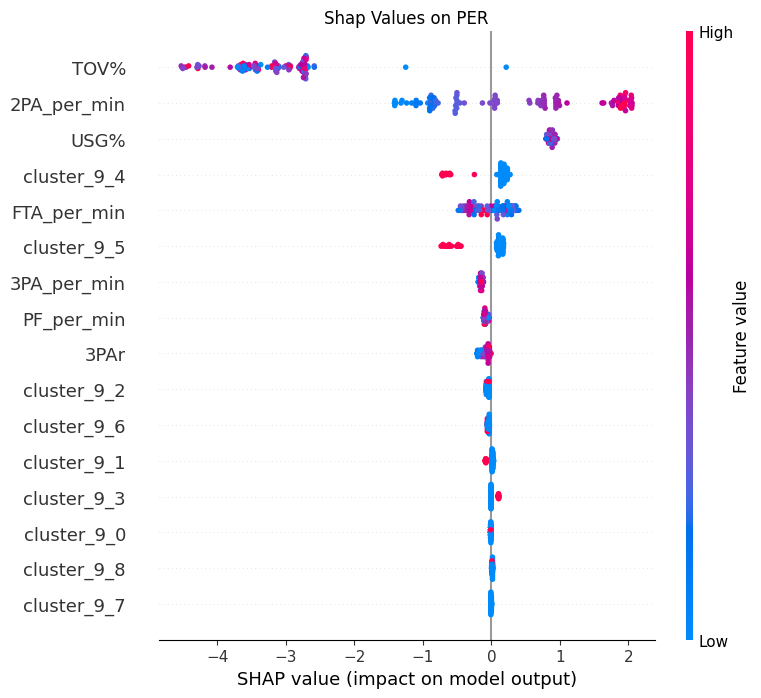

In [92]:
explainer = shap.TreeExplainer(rf_mod_per)
shap_values = explainer(X_test_original)

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title('Shap Values on PER')
plt.savefig("../03_progress/plots/shap_beeswarm_per.png", bbox_inches='tight', dpi=300)
plt.show()

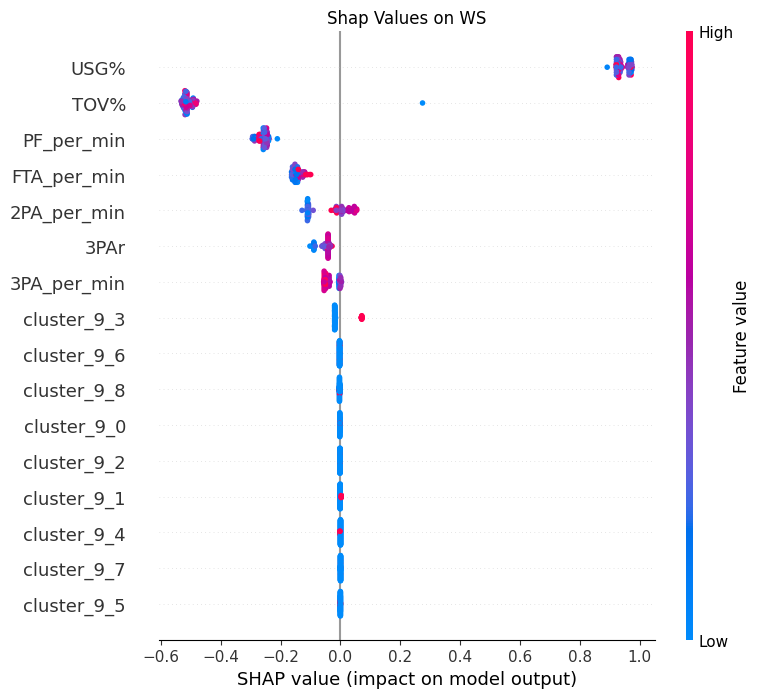

In [93]:
explainer = shap.TreeExplainer(rf_mod_ws)
shap_values = explainer(X_test_original)

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title('Shap Values on WS')
plt.savefig("../03_progress/plots/shap_beeswarm_ws.png", bbox_inches='tight', dpi=300)
plt.show()

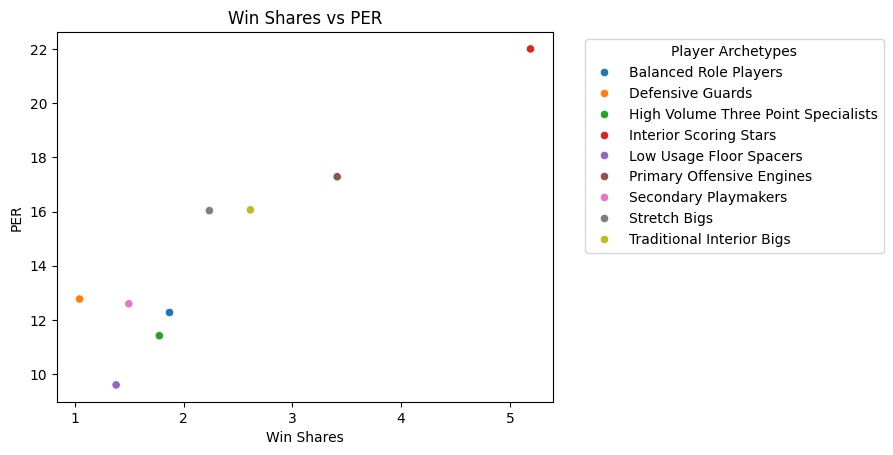

In [83]:
df_means = df[['PER', 'WS', 'cluster_9_label']].groupby(by='cluster_9_label').mean()

sns.scatterplot(data=df_means, x='WS', y='PER', hue='cluster_9_label')

plt.title("Win Shares vs PER")
plt.xlabel("Win Shares")
plt.ylabel("PER")
plt.legend(
    title="Player Archetypes",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

In [84]:
df_means

,PER,WS
cluster_9_label,,
Balanced Role Players,12.273563,1.870115
Defensive Guards,12.771429,1.042857
High Volume Three Point Specialists,11.416667,1.776190
Interior Scoring Stars,22.011111,5.188889
Low Usage Floor Spacers,9.597531,1.379012
Primary Offensive Engines,17.289412,3.411765
Secondary Playmakers,12.595652,1.495652
Stretch Bigs,16.036667,2.236667
Traditional Interior Bigs,16.065000,2.613333


### Find under and overperformers

In [90]:
df['perf_label_per'] = np.where(
    df['lin_resid_per'] > lin_per_test_rmse, 'Overperformer',
    np.where(df['lin_resid_per'] < -lin_per_test_rmse, 'Underperformer', 'As Expected')
)

df['perf_label_ws'] = np.where(
    df['rf_resid_ws'] > rf_ws_test_rmse, 'Overperformer',
    np.where(df['rf_resid_ws'] < -rf_ws_test_rmse, 'Underperformer', 'As Expected')
)

df_performance = df[['Player', 'Team', 'perf_label_per', 'perf_label_ws']]

df_performance

,Player,Team,perf_label_per,perf_label_ws
0,Shai Gilgeous-Alexander,OKC,Overperformer,Overperformer
1,Giannis Antetokounmpo,MIL,Overperformer,Overperformer
2,Nikola Jokić,DEN,Overperformer,Overperformer
3,Luka Dončić,DAL,Overperformer,As Expected
4,Luka Dončić,LAL,Overperformer,Overperformer
...,...,...,...,...
546,Spencer Jones,DEN,Underperformer,As Expected
547,Xavier Tillman Sr.,BOS,Underperformer,As Expected
548,Luke Travers,CLE,Underperformer,As Expected
549,Justin Minaya,POR,As Expected,As Expected


In [91]:
df[['Player', 'Team', 'rf_resid_ws']].sort_values(by='rf_resid_ws')

,Player,Team,rf_resid_ws
490,Damion Lee,PHO,-5.293609
430,Marvin Bagley III,WAS,-4.999794
135,Malcolm Brogdon,WAS,-4.441081
314,Nae'Qwan Tomlin,CLE,-4.261192
271,Jaylen Nowell,NOP,-4.134132
...,...,...,...
1,Giannis Antetokounmpo,MIL,8.730684
21,Karl-Anthony Towns,NYK,9.045201
65,Tyrese Haliburton,IND,9.175609
2,Nikola Jokić,DEN,15.371315


In [95]:
df[df['cluster_9'] == 4]['cluster_9_label']

143    Low Usage Floor Spacers
162    Low Usage Floor Spacers
165    Low Usage Floor Spacers
184    Low Usage Floor Spacers
197    Low Usage Floor Spacers
                ...           
546    Low Usage Floor Spacers
547    Low Usage Floor Spacers
548    Low Usage Floor Spacers
549    Low Usage Floor Spacers
550    Low Usage Floor Spacers
Name: cluster_9_label, Length: 81, dtype: object

In [96]:
df[df['cluster_9'] == 3]['cluster_9_label']

3      Primary Offensive Engines
4      Primary Offensive Engines
5      Primary Offensive Engines
6      Primary Offensive Engines
7      Primary Offensive Engines
                 ...            
350    Primary Offensive Engines
364    Primary Offensive Engines
409    Primary Offensive Engines
490    Primary Offensive Engines
520    Primary Offensive Engines
Name: cluster_9_label, Length: 85, dtype: object

In [97]:
df[df['cluster_9'] == 5]['cluster_9_label']

70     Balanced Role Players
74     Balanced Role Players
83     Balanced Role Players
95     Balanced Role Players
99     Balanced Role Players
               ...          
493    Balanced Role Players
500    Balanced Role Players
514    Balanced Role Players
528    Balanced Role Players
541    Balanced Role Players
Name: cluster_9_label, Length: 87, dtype: object